# PSet 1 — Problem 1 (Python)

This notebook solves:
- **1.1** Vandermonde linear system and conditioning
- **1.2** Polynomial approximation of $\log(s)$ on $[1,10]$

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

## 1.1 Vandermonde matrices

We solve $Ax=b$ where $A_{ij} = i^{n-j}$ and $b_i = \sum_{k=0}^{n-1} i^k$ (with $b_1=n$).
True solution is $x=\mathbf{1}$.

In [3]:
def vandermonde_system(n: int):
    i = np.arange(1, n + 1, dtype=float)
    powers = (n - np.arange(1, n + 1))[None, :]
    A = i[:, None] ** powers
    b = (i**n - 1.0) / (i - 1.0)
    b[0] = float(n)
    return A, b


for n in [5, 10, 15]:
    A, b = vandermonde_system(n)
    x = np.linalg.solve(A, b)
    err_x = np.linalg.norm(x - 1.0)
    err_res = np.linalg.norm(A @ x - b)
    condA = np.linalg.cond(A)
    print(f"n={n:2d}  cond(A)={condA:10.3e}   ||x-1||={err_x:10.3e}   ||Ax-b||={err_res:10.3e}")

n= 5  cond(A)= 2.617e+04   ||x-1||= 3.199e-13   ||Ax-b||= 1.137e-13
n=10  cond(A)= 2.106e+12   ||x-1||= 7.889e-07   ||Ax-b||= 1.814e-07
n=15  cond(A)= 2.582e+21   ||x-1||= 2.169e+02   ||Ax-b||= 2.291e+00


/var/folders/jn/33qbdrsn2055lsl5jw84hjph0000gn/T/ipykernel_6085/3711802700.py:5: RuntimeWarning: invalid value encountered in divide
  b = (i**n - 1.0) / (i - 1.0)


In [16]:
n = 15
A,b = vandermonde_system(n)
x = np.linalg.solve(A,b)
print("the condition number of A is: ", np.linalg.cond(A))
print("the vector x is: ", x, "and the euclidean norm of x-1 is: ", np.linalg.norm(x-1))

the condition number of A is:  2.5824111067829366e+21
the vector x is:  [   1.        1.        1.        0.9999    1.001     0.9864    1.1339
    0.0281    6.2086  -19.4248   58.4144 -110.4995  141.2697 -100.1863
   32.0686] and the euclidean norm of x-1 is:  216.91778962599824


/var/folders/jn/33qbdrsn2055lsl5jw84hjph0000gn/T/ipykernel_6085/3711802700.py:5: RuntimeWarning: invalid value encountered in divide
  b = (i**n - 1.0) / (i - 1.0)


## 1.2 Polynomial approximation of $\log(s)$

We approximate $\log(s)$ on $[1,10]$ using an $(n-1)$-degree polynomial fit on $m=100$ equally-spaced nodes, then evaluate on a fine grid.

We solve the overdetermined system by least squares.

n= 5  cond(A)= 7.988e+04   ||error||_2= 2.945e-01
n=10  cond(A)= 3.976e+11   ||error||_2= 5.921e-03
n=15  cond(A)= 2.710e+18   ||error||_2= 7.893e-01
n=20  cond(A)= 1.365e+25   ||error||_2= 1.412e+01


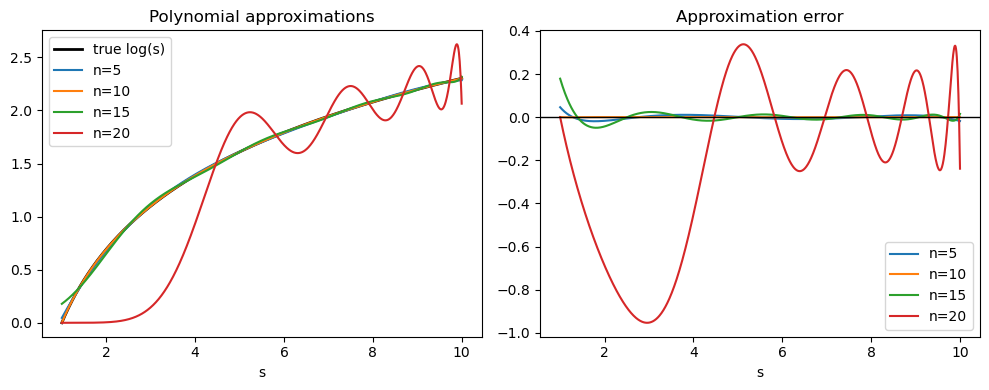

In [17]:
def poly_basis(s: np.ndarray, n: int) -> np.ndarray:
    s = np.asarray(s)
    return s[:, None] ** np.arange(n)[None, :]


m = 100
s = np.linspace(1.0, 10.0, m)
b = np.log(s)

ss = np.linspace(1.0, 10.0, 1000)
bb = np.log(ss)

ns = [5, 10, 15, 20]
fits = {}

for n in ns:
    A = poly_basis(s, n)
    x, *_ = np.linalg.lstsq(A, b, rcond=None)
    condA = np.linalg.cond(A)
    AA = poly_basis(ss, n)
    pred = AA @ x
    err = pred - bb
    err_norm = np.linalg.norm(err)
    fits[n] = (pred, err, condA, err_norm)
    print(f"n={n:2d}  cond(A)={condA:10.3e}   ||error||_2={err_norm:10.3e}")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(ss, bb, 'k', linewidth=2, label='true log(s)')
for n in ns:
    plt.plot(ss, fits[n][0], label=f'n={n}')
plt.title('Polynomial approximations')
plt.xlabel('s')
plt.legend()

plt.subplot(1, 2, 2)
for n in ns:
    plt.plot(ss, fits[n][1], label=f'n={n}')
plt.axhline(0.0, color='k', linewidth=1)
plt.title('Approximation error')
plt.xlabel('s')
plt.legend()
plt.tight_layout()
plt.show()